## Step 1: Baseline feature and target table

The baselines use engineered features, which already sit in Process.csv (one row per batch). The four targets are in Laboratory.csv. Here I join them, pick the targets, and drop anything that leaks the answer. Output: one clean table for LASSO and XGBoost.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE=Path(r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets")
TRAJ=BASE/"Process"

proc=pd.read_csv(BASE/"Process.csv",sep=";")
lab=pd.read_csv(BASE/"Laboratory.csv",sep=";")

print("process",proc.shape)
print("lab",lab.shape)

process (1005, 35)
lab (1005, 55)


In [2]:
df=proc.merge(lab,on="batch",suffixes=("","_lab"))
print("merged",df.shape)
print("batches kept",df["batch"].nunique())

merged (1005, 89)
batches kept 1005


## Pick the four targets

These are the quality attributes the model predicts: dissolution, hardness, weight RSD, tensile strength. I pull them into y and confirm none are missing.

In [3]:
targets=["dissolution_av","tbl_av_hardness","tbl_rsd_weight","fct_tensile"]
y=df[targets].copy()

print("y",y.shape)
print(y.isna().sum())

y (1005, 4)
dissolution_av     0
tbl_av_hardness    0
tbl_rsd_weight     0
fct_tensile        0
dtype: int64


## Drop the leakage, build X

Product identity (code, batch, strength, size) is removed because the audit showed code alone explains most of the hardness variance. Process.csv also carries Drug release columns, which are basically the dissolution answer, so those go too. What remains is the honest engineered feature set.

In [4]:
leak=["batch","code","code_lab","strength","size","start",
      "Drug release average (%)","Drug release min (%)"]

X=proc.drop(columns=[c for c in leak if c in proc.columns]).copy()

print("X",X.shape)
print("X columns:")
print(list(X.columns))

X (1005, 31)
X columns:
['tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'total_waste', 'startup_waste', 'weekend', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'SREL_production_max', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'stiffness_max', 'stiffness_min', 'ejection_mean', 'ejection_max', 'ejection_min', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean', 'Residual solvent', 'Total impurities', 'Impurity O', 'Impurity L']


## Encode weekend, final check

weekend is text (no/yes), which the models cannot read, so I map it to 0/1. Then I confirm every feature is numeric and nothing is missing.

In [5]:
X["weekend"]=X["weekend"].map({"no":0,"yes":1}).astype(int)

print("X",X.shape)
print("non-numeric cols:",list(X.select_dtypes(exclude="number").columns))
print("missing values:",int(X.isna().sum().sum()))

X (1005, 31)
non-numeric cols: []
missing values: 72


In [6]:
miss=X.isna().sum()
print(miss[miss>0])

Residual solvent    18
Total impurities    18
Impurity O          18
Impurity L          18
dtype: int64


## Drop the chemistry columns

The only missing values sit in four incoming-material chemistry columns (18 batches each). These are also the only features whose status as a valid input is ambiguous. Dropping them gives a clean process-only feature set: no gaps, no leakage doubt, and it matches the 27 features used in the feasibility test.

In [7]:
chem=["Residual solvent","Total impurities","Impurity O","Impurity L"]
X=X.drop(columns=[c for c in chem if c in X.columns])

print("X",X.shape)
print("missing values:",int(X.isna().sum().sum()))
print(list(X.columns))

X (1005, 27)
missing values: 0
['tbl_speed_mean', 'tbl_speed_change', 'tbl_speed_0_duration', 'total_waste', 'startup_waste', 'weekend', 'fom_mean', 'fom_change', 'SREL_startup_mean', 'SREL_production_mean', 'SREL_production_max', 'main_CompForce mean', 'main_CompForce_sd', 'main_CompForce_median', 'pre_CompForce_mean', 'tbl_fill_mean', 'tbl_fill_sd', 'cyl_height_mean', 'stiffness_mean', 'stiffness_max', 'stiffness_min', 'ejection_mean', 'ejection_max', 'ejection_min', 'Startup_tbl_fill_maxDifference', 'Startup_main_CompForce_mean', 'Startup_tbl_fill_mean']


## Keep code aside for grouping

Product code is not a feature (it leaks), but I need it later to make the leave-one-product-code-out splits. So I store it separately, never inside X.

In [8]:
groups=df["code"].copy()

print("X",X.shape)
print("y",y.shape)
print("groups",groups.shape,"unique codes",groups.nunique())

X (1005, 27)
y (1005, 4)
groups (1005,) unique codes 25


## Step 2: Baseline setup

I build the two baselines from the paper: LASSO and XGBoost. Each predicts all four targets. To keep it honest I cross-validate with GroupKFold on product code, so no product appears in both train and test. I also add a predict-the-mean dummy as the floor the models must beat.

In [9]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

gkf=GroupKFold(n_splits=5)

print("targets:",targets)
print("features:",X.shape[1])
print("cv: GroupKFold 5 splits on code")

targets: ['dissolution_av', 'tbl_av_hardness', 'tbl_rsd_weight', 'fct_tensile']
features: 27
cv: GroupKFold 5 splits on code


## Train and score the three models

For each target I run the dummy, LASSO and XGBoost through the 5 grouped folds and record RMSE on the held-out fold. LASSO needs scaling so it goes in a pipeline. The dummy is the floor: any real model must beat it.

In [10]:
import warnings
warnings.filterwarnings("ignore")

models={
"dummy":DummyRegressor(strategy="mean"),
"lasso":Pipeline([("sc",StandardScaler()),("m",Lasso(alpha=0.1,max_iter=10000))]),
"xgb":XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,random_state=42,verbosity=0)
}

results={}
for tgt in targets:
    yt=y[tgt].values
    results[tgt]={}
    for name,model in models.items():
        rmses=[]
        for tr,te in gkf.split(X,yt,groups=groups):
            model.fit(X.iloc[tr],yt[tr])
            pred=model.predict(X.iloc[te])
            rmses.append(np.sqrt(mean_squared_error(yt[te],pred)))
        results[tgt][name]=np.mean(rmses)
    print(tgt,"done")

print("all targets done")

dissolution_av done
tbl_av_hardness done
tbl_rsd_weight done
fct_tensile done
all targets done


## Results table: model vs baseline

I put the RMSE for all three models side by side, one row per target. Lower is better. The check is simple: LASSO and XGBoost should both beat the dummy.

In [11]:
table=pd.DataFrame(results).T
table=table[["dummy","lasso","xgb"]]
table=table.round(3)

print(table)

                  dummy  lasso    xgb
dissolution_av    3.512  3.119  3.147
tbl_av_hardness  11.439  6.619  5.004
tbl_rsd_weight    0.558  0.538  0.605
fct_tensile       0.419  0.343  0.255


## Save the results table

I write the comparison table to CSV so it can go into the report and the weekly deliverable.

In [12]:
table.to_csv(BASE/"baseline_results.csv")
print("saved to",BASE/"baseline_results.csv")
print(table)

saved to C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\baseline_results.csv
                  dummy  lasso    xgb
dissolution_av    3.512  3.119  3.147
tbl_av_hardness  11.439  6.619  5.004
tbl_rsd_weight    0.558  0.538  0.605
fct_tensile       0.419  0.343  0.255


## Step 3: Tuned baselines with nested CV

The first baselines used guessed settings. Here I tune them properly. The outer GroupKFold tests on unseen products. Inside each fold, an inner GroupKFold picks the best settings using only the training products. This gives each baseline its fair best shot, so any later comparison against the deep model is honest.

In [13]:
from sklearn.model_selection import GridSearchCV

inner=GroupKFold(n_splits=4)
outer=GroupKFold(n_splits=5)

lasso_grid={"m__alpha":[0.01,0.05,0.1,0.5,1.0]}
xgb_grid={"n_estimators":[200,400],"max_depth":[3,4,6],"learning_rate":[0.03,0.1]}

print("inner: GroupKFold 4 | outer: GroupKFold 5")
print("lasso settings tried:",len(lasso_grid["m__alpha"]))
print("xgb settings tried:",2*3*2)

inner: GroupKFold 4 | outer: GroupKFold 5
lasso settings tried: 5
xgb settings tried: 12


## Run the tuned baselines

For each target I run nested CV. The inner loop picks the best settings, the tuned model is scored on the unseen products, and I average the RMSE across the outer folds. This takes longer than the first pass because it trains many models.

In [14]:
tuned={}
for tgt in targets:
    yt=y[tgt].values
    tuned[tgt]={}
    for name in ["lasso","xgb"]:
        rmses=[]
        for tr,te in outer.split(X,yt,groups=groups):
            Xtr,Xte=X.iloc[tr],X.iloc[te]
            ytr,yte=yt[tr],yt[te]
            gtr=groups.iloc[tr]
            if name=="lasso":
                base=Pipeline([("sc",StandardScaler()),("m",Lasso(max_iter=10000))])
                grid=lasso_grid
            else:
                base=XGBRegressor(random_state=42,verbosity=0)
                grid=xgb_grid
            search=GridSearchCV(base,grid,cv=inner.split(Xtr,ytr,groups=gtr),
                                scoring="neg_root_mean_squared_error")
            search.fit(Xtr,ytr)
            pred=search.best_estimator_.predict(Xte)
            rmses.append(np.sqrt(mean_squared_error(yte,pred)))
        tuned[tgt][name]=np.mean(rmses)
    print(tgt,"done")

print("all targets done")

dissolution_av done
tbl_av_hardness done
tbl_rsd_weight done
fct_tensile done
all targets done


## Tuned vs first-pass results

I put the tuned RMSE next to the first-pass numbers. Lower is better. This shows whether proper tuning gave the baselines a meaningful lift, which matters because the deep model will have to beat the tuned version, not the weak one.

In [15]:
tuned_table=pd.DataFrame(tuned).T[["lasso","xgb"]].round(3)
tuned_table.columns=["lasso_tuned","xgb_tuned"]

compare=table.join(tuned_table)
print(compare)

                  dummy  lasso    xgb  lasso_tuned  xgb_tuned
dissolution_av    3.512  3.119  3.147        3.102      3.010
tbl_av_hardness  11.439  6.619  5.004        6.658      5.108
tbl_rsd_weight    0.558  0.538  0.605        0.526      0.570
fct_tensile       0.419  0.343  0.255        0.332      0.256


In [16]:
compare.to_csv(BASE/"baseline_results_tuned.csv")
print("saved to",BASE/"baseline_results_tuned.csv")
print(compare)

saved to C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\baseline_results_tuned.csv
                  dummy  lasso    xgb  lasso_tuned  xgb_tuned
dissolution_av    3.512  3.119  3.147        3.102      3.010
tbl_av_hardness  11.439  6.619  5.004        6.658      5.108
tbl_rsd_weight    0.558  0.538  0.605        0.526      0.570
fct_tensile       0.419  0.343  0.255        0.332      0.256


## Step 4: All evaluation metrics

The mentor asked for all evaluation metrics, not just RMSE. Here I report three: RMSE and MAE (error size, lower is better) and R squared (variation explained, higher is better). I compute them for every model and target under the same grouped CV so the comparison stays fair.

In [17]:
from sklearn.metrics import mean_absolute_error,r2_score

def score_model(model,Xd,yd,grp):
    rmse,mae,r2=[],[],[]
    for tr,te in gkf.split(Xd,yd,groups=grp):
        model.fit(Xd.iloc[tr],yd[tr])
        pred=model.predict(Xd.iloc[te])
        rmse.append(np.sqrt(mean_squared_error(yd[te],pred)))
        mae.append(mean_absolute_error(yd[te],pred))
        r2.append(r2_score(yd[te],pred))
    return np.mean(rmse),np.mean(mae),np.mean(r2)

allmetrics=[]
for tgt in targets:
    yt=y[tgt].values
    for name,model in models.items():
        rm,ma,r2=score_model(model,X,yt,groups)
        allmetrics.append({"target":tgt,"model":name,
                           "RMSE":round(rm,3),"MAE":round(ma,3),"R2":round(r2,3)})

metrics_table=pd.DataFrame(allmetrics)
print(metrics_table.to_string(index=False))

         target model   RMSE   MAE     R2
 dissolution_av dummy  3.512 2.836 -0.329
 dissolution_av lasso  3.119 2.416 -0.062
 dissolution_av   xgb  3.147 2.479 -0.077
tbl_av_hardness dummy 11.439 8.150 -0.347
tbl_av_hardness lasso  6.619 5.290  0.127
tbl_av_hardness   xgb  5.004 3.844  0.525
 tbl_rsd_weight dummy  0.558 0.301 -0.020
 tbl_rsd_weight lasso  0.538 0.267  0.059
 tbl_rsd_weight   xgb  0.605 0.297 -0.299
    fct_tensile dummy  0.419 0.381 -2.674
    fct_tensile lasso  0.343 0.288 -1.494
    fct_tensile   xgb  0.255 0.197 -0.319


In [18]:
metrics_table.to_csv(BASE/"baseline_metrics_all.csv",index=False)
print("saved to",BASE/"baseline_metrics_all.csv")

saved to C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\baseline_metrics_all.csv


## Hardness target distribution

Hardness has the highest and most variable RMSE across all models. I look at its distribution to understand why: high variance, skew, or spread across product codes would all make it harder to predict and explain the larger errors.

hardness stats:
  mean: 54.87
  std: 12.67
  min: 27 max: 102
  coefficient of variation: 0.231

coefficient of variation, all targets:
  dissolution_av: 0.037
  tbl_av_hardness: 0.231
  tbl_rsd_weight: 0.525
  fct_tensile: 0.223


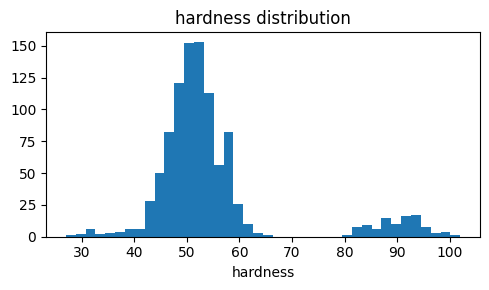

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

h=y["tbl_av_hardness"].values
print("hardness stats:")
print("  mean:",round(h.mean(),2))
print("  std:",round(h.std(),2))
print("  min:",round(h.min(),2),"max:",round(h.max(),2))
print("  coefficient of variation:",round(h.std()/h.mean(),3))

# compare CV across all four targets for context
print("\ncoefficient of variation, all targets:")
for t in ["dissolution_av","tbl_av_hardness","tbl_rsd_weight","fct_tensile"]:
    v=y[t].values
    print(f"  {t}: {round(v.std()/v.mean(),3)}")

plt.figure(figsize=(5,3))
plt.hist(h,bins=40); plt.title("hardness distribution"); plt.xlabel("hardness")
plt.tight_layout(); plt.show()

## Do the two hardness clusters map to product codes

The hardness distribution is bimodal, with a low cluster around 50 and a high cluster around 85 to 95. Here I check whether these two clusters correspond to different product codes. I split the batches at hardness 70 and look at which codes fall in each cluster, and whether any code appears in both. If the clusters are distinct product families, this is a dataset characteristic for the methodology and it affects how the leave one product code out test should be read.

In [1]:
import pandas as pd
import numpy as np

BASE=r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets"
proc=pd.read_csv(BASE+r"\Process.csv",sep=";")
lab=pd.read_csv(BASE+r"\Laboratory.csv",sep=";")
df=proc.merge(lab,on="batch",suffixes=("","_lab"))

h=df["tbl_av_hardness"].values
codes=df["code"].values

hi=h>=70
hc=pd.DataFrame({"code":codes,"hardness":h,"cluster":np.where(hi,"high","low")})

high_codes=set(hc[hi]["code"].unique())
low_codes=set(hc[~hi]["code"].unique())
both=high_codes&low_codes

print("high cluster:",hi.sum(),"batches | low cluster:",(~hi).sum(),"batches")
print("high cluster codes:",sorted(high_codes))
print("low cluster codes:",sorted(low_codes))
print("codes in both:",sorted(both) if both else "none")
print("codes only high:",sorted(high_codes-low_codes))

high cluster: 98 batches | low cluster: 907 batches
high cluster codes: [np.int64(4), np.int64(8), np.int64(15), np.int64(20), np.int64(24)]
low cluster codes: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25)]
codes in both: none
codes only high: [np.int64(4), np.int64(8), np.int64(15), np.int64(20), np.int64(24)]


In [2]:
finding={
"high_cluster_codes":[4,8,15,20,24],
"high_cluster_batches":98,
"low_cluster_batches":907,
"overlap":"none",
"note":"hardness bimodality maps to five distinct high-hardness product codes with no overlap; OOD test on a high-hardness code (e.g. code 15) mixes distribution shift with hardness-regime shift"
}
import json
with open(r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets\hardness_cluster_finding.json","w") as fh:
    json.dump(finding,fh,indent=2)
print(json.dumps(finding,indent=2))

{
  "high_cluster_codes": [
    4,
    8,
    15,
    20,
    24
  ],
  "high_cluster_batches": 98,
  "low_cluster_batches": 907,
  "overlap": "none",
  "note": "hardness bimodality maps to five distinct high-hardness product codes with no overlap; OOD test on a high-hardness code (e.g. code 15) mixes distribution shift with hardness-regime shift"
}


## Do the high-hardness codes land evenly across the folds

The five high-hardness product codes carry the entire upper cluster. If a grouped split happens to place most of them in one test fold, the model trains with almost no high-hardness products and that fold's hardness RMSE will be inflated. Here I check how the five codes are distributed across the three folds used in the main evaluation.

In [1]:
import numpy as np
import pickle
from sklearn.model_selection import GroupKFold

BASE=r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets"
with open(BASE+r"\assembled_trajectories.pkl","rb") as fh:
    data=pickle.load(fh)
X_traj=data["X_traj"]
y_arr=data["y_arr"]
groups=data["groups"]

high_codes={4,8,15,20,24}
gkf=GroupKFold(n_splits=3)

print("fold assignment against the high-hardness cluster\n")
for fold,(tr,te) in enumerate(gkf.split(X_traj,y_arr[:,0],groups=groups)):
    te_codes=sorted(int(c) for c in np.unique(groups[te]))
    tr_codes=sorted(int(c) for c in np.unique(groups[tr]))
    hi_te=[c for c in te_codes if c in high_codes]
    hi_tr=[c for c in tr_codes if c in high_codes]
    n_hi_batches=int(np.isin(groups[te],list(high_codes)).sum())
    hardness_te=y_arr[te,1]
    print(f"fold {fold+1}")
    print(f"  test codes            {te_codes}")
    print(f"  high-cluster in test  {hi_te}  ({len(hi_te)} of 5)")
    print(f"  high-cluster in train {hi_tr}  ({len(hi_tr)} of 5)")
    print(f"  high-cluster batches in test  {n_hi_batches}")
    print(f"  test hardness mean {hardness_te.mean():.1f}, std {hardness_te.std():.1f}")
    print()

fold assignment against the high-hardness cluster

fold 1
  test codes            [2, 3, 4, 9, 15, 17, 18, 20]
  high-cluster in test  [4, 15, 20]  (3 of 5)
  high-cluster in train [8, 24]  (2 of 5)
  high-cluster batches in test  90
  test hardness mean 63.0, std 17.1

fold 2
  test codes            [6, 11, 12, 16, 21, 23, 24, 25]
  high-cluster in test  [24]  (1 of 5)
  high-cluster in train [4, 8, 15, 20]  (4 of 5)
  high-cluster batches in test  6
  test hardness mean 50.9, std 7.4

fold 3
  test codes            [1, 5, 7, 8, 10, 13, 14, 19, 22]
  high-cluster in test  [8]  (1 of 5)
  high-cluster in train [4, 15, 20, 24]  (4 of 5)
  high-cluster batches in test  2
  test hardness mean 50.8, std 6.0



## How many batches does each high-hardness code carry

Before assigning codes to folds I check how many batches each of the five high-hardness codes contributes. Codes must stay intact within a fold to preserve the leakage-safe grouping, so the achievable balance depends on how evenly these batch counts divide.

In [1]:
import numpy as np
import pickle
from collections import Counter

BASE=r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets"
with open(BASE+r"\assembled_trajectories.pkl","rb") as fh:
    data=pickle.load(fh)
y_arr=data["y_arr"]
groups=data["groups"]

high_codes=[4,8,15,20,24]
counts=Counter(int(c) for c in groups)

print("high-hardness codes and their batch counts")
tot=0
for c in high_codes:
    print(f"  code {c:<3} {counts[c]:>4} batches")
    tot+=counts[c]
print(f"  total {tot} batches, ideal per fold {tot/3:.1f}")

print("\nlow-cluster codes")
low=[int(c) for c in np.unique(groups) if int(c) not in high_codes]
low_tot=sum(counts[c] for c in low)
print(f"  {len(low)} codes, {low_tot} batches, ideal per fold {low_tot/3:.1f}")

high-hardness codes and their batch counts
  code 4     22 batches
  code 8      2 batches
  code 15    64 batches
  code 20     4 batches
  code 24     6 batches
  total 98 batches, ideal per fold 32.7

low-cluster codes
  20 codes, 907 batches, ideal per fold 302.3


## Stratified fold construction

Following the diagnostic, code 15 is held out entirely as the high-cluster case for the out-of-distribution test, and is excluded from the main cross-validation. The remaining four high-hardness codes (4, 8, 20, 24) are distributed across the three folds, giving 22, 6 and 6 high-cluster batches per fold. Code 4 carries 22 batches on its own and cannot be split without breaking the grouping, so this is the best balance achievable while keeping codes intact. It is a large improvement on the plain GroupKFold split, which placed 90 of the 98 high-cluster batches in a single fold. The low-cluster codes are then distributed to keep the folds similar in total size. Codes stay intact within a fold to preserve the leakage-safe grouping. The distribution is verified before any training.

In [1]:
import numpy as np
import pickle
from collections import Counter

BASE=r"C:\Users\Arpit Joshua Elias\OneDrive\Desktop\Pharma datasets"
with open(BASE+r"\assembled_trajectories.pkl","rb") as fh:
    data=pickle.load(fh)
y_arr=data["y_arr"]
groups=data["groups"]

SEED=42
counts=Counter(int(c) for c in groups)
high_codes=[4,8,15,20,24]
ood_code=15
high_in_cv=[4,8,20,24]
low_codes=sorted(int(c) for c in np.unique(groups) if int(c) not in high_codes)

n_splits=3
fold_high=[[] for _ in range(n_splits)]

fold_high[0]=[4]
fold_high[1]=[24]
fold_high[2]=[8,20]

fold_codes=[list(f) for f in fold_high]

rng=np.random.RandomState(SEED)
low_shuf=list(rng.permutation(low_codes))
low_sorted=sorted(low_shuf,key=lambda c:-counts[c])
fold_batches=[sum(counts[c] for c in fold_codes[f]) for f in range(n_splits)]
for c in low_sorted:
    f=int(np.argmin(fold_batches))
    fold_codes[f].append(c)
    fold_batches[f]+=counts[c]

print("OOD held-out code:",ood_code,f"({counts[ood_code]} batches)")
print()
for f in range(n_splits):
    codes=sorted(fold_codes[f])
    hi=[c for c in codes if c in high_in_cv]
    hi_batches=sum(counts[c] for c in hi)
    tot=sum(counts[c] for c in codes)
    print(f"fold {f+1}")
    print(f"  codes            {codes}")
    print(f"  high-cluster     {hi}  ->  {hi_batches} batches")
    print(f"  total batches    {tot}")
    print()

all_cv=[c for f in fold_codes for c in f]
print("sanity: code 15 excluded from CV:",15 not in all_cv)
print("sanity: all CV codes unique:",len(all_cv)==len(set(all_cv)))
print("sanity: CV + OOD covers all 25 codes:",len(set(all_cv))+1==25)

OOD held-out code: 15 (64 batches)

fold 1
  codes            [np.int64(1), np.int64(2), 4, np.int64(6), np.int64(7), np.int64(9), np.int64(13), np.int64(18), np.int64(25)]
  high-cluster     [4]  ->  22 batches
  total batches    314

fold 2
  codes            [np.int64(10), np.int64(11), np.int64(17), np.int64(19), np.int64(22), 24]
  high-cluster     [24]  ->  6 batches
  total batches    313

fold 3
  codes            [np.int64(3), np.int64(5), 8, np.int64(12), np.int64(14), np.int64(16), 20, np.int64(21), np.int64(23)]
  high-cluster     [8, 20]  ->  6 batches
  total batches    314

sanity: code 15 excluded from CV: True
sanity: all CV codes unique: True
sanity: CV + OOD covers all 25 codes: True


In [2]:
import json

fold_assignment={
"ood_code":15,
"n_splits":3,
"folds":{f"fold_{f+1}":sorted(int(c) for c in fold_codes[f]) for f in range(n_splits)},
"high_cluster_per_fold":{f"fold_{f+1}":int(sum(counts[c] for c in fold_codes[f] if c in high_in_cv)) for f in range(n_splits)}
}
with open(BASE+r"\fold_assignment.json","w") as fh:
    json.dump(fold_assignment,fh,indent=2)
print(json.dumps(fold_assignment,indent=2))

{
  "ood_code": 15,
  "n_splits": 3,
  "folds": {
    "fold_1": [
      1,
      2,
      4,
      6,
      7,
      9,
      13,
      18,
      25
    ],
    "fold_2": [
      10,
      11,
      17,
      19,
      22,
      24
    ],
    "fold_3": [
      3,
      5,
      8,
      12,
      14,
      16,
      20,
      21,
      23
    ]
  },
  "high_cluster_per_fold": {
    "fold_1": 22,
    "fold_2": 6,
    "fold_3": 6
  }
}
